# Thesis: Reclaimed Timber in Deep Generative Design

**Notebook:** c25_26_27_optimizer_workflow_with_cost_and_ILP  
**Author:** Jasper Cluistra     
**Last Updated:** 2026-02-27

## Cost and ILP Optimization Workflow

Generate a cost matrix for the geometry using timber datasets, then use ILP to find the best assignments.

**Inputs:** CSV timber dataset, Digital geometry  
**Outputs:** Best match for each structural element

# IMPORTING

In [11]:
import config
import json
import pandas as pd

stock_path = config.TIMBER_STOCK_PATH / 'complete_timber.csv'
json_path = config.DATA_IO_PATH / "search_space.json"

with open(json_path, "r") as f:
    optimizer_search_space = json.load(f)

print(f"Search space loaded. The optimizer can control {len(optimizer_search_space)} parameters.")

# Try common combinations
read_attempts = [
    {"sep": ",", "encoding": "utf-8"},
    {"sep": ";", "encoding": "utf-8"},
    {"sep": ",", "encoding": "latin1"},
    {"sep": ";", "encoding": "latin1"},
]

df_input_stock = None
for opts in read_attempts:
    try:
        df_try = pd.read_csv(stock_path, **opts)  # type: ignore
        # Valid if we get more than 1 column
        if df_try.shape[1] > 1:
            df_input_stock = df_try
            print(f"Loaded with sep='{opts['sep']}' and encoding='{opts['encoding']}'")
            break
    except Exception:
        pass

if df_input_stock is None:
    raise ValueError("Could not parse CSV with tested delimiter/encoding combinations.")

# Clean column names
df_input_stock.columns = df_input_stock.columns.str.strip()

print("Detected columns:", df_input_stock.columns.tolist())
print(f"\nDataset contains {df_input_stock.shape[0]} elements\n")
display(df_input_stock.head())

Search space loaded. The optimizer can control 73 parameters.
Loaded with sep=';' and encoding='utf-8'
Detected columns: ['Member_ID', 'State', 'Length', 'Depth', 'Width', 'f_mk', 'f_tk', 'E_modulus_eff', 'E_modulus_005', 'f_vk', 'f_c0k', 'k_density', 'mean_density', 'Origin_Country', 'Transport_Dist', 'EmissionFactor']

Dataset contains 506 elements



,Member_ID,State,Length,Depth,Width,f_mk,f_tk,E_modulus_eff,E_modulus_005,f_vk,f_c0k,k_density,mean_density,Origin_Country,Transport_Dist,EmissionFactor
0,NS_00000,0,1450.0,100.0,38.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Germany,301.53,0.1796
1,NS_00001,0,1450.0,100.0,50.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,49.24,0.1756
2,NS_00002,0,1450.0,100.0,63.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,45.39,0.1735
3,NS_00003,0,1450.0,100.0,75.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Germany,341.15,0.1735
4,NS_00004,0,1450.0,100.0,100.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,50.13,0.1757


# GEOMETRY

Geometry: 39 nodes, 120 members
Length range [m]: 1.328 - 4.889


,edge_id,V1,V2,length_m
0,e0,0,1,2.625
1,e1,0,6,2.625
2,e2,1,2,2.250
3,e3,1,7,2.281
4,e4,2,3,4.500


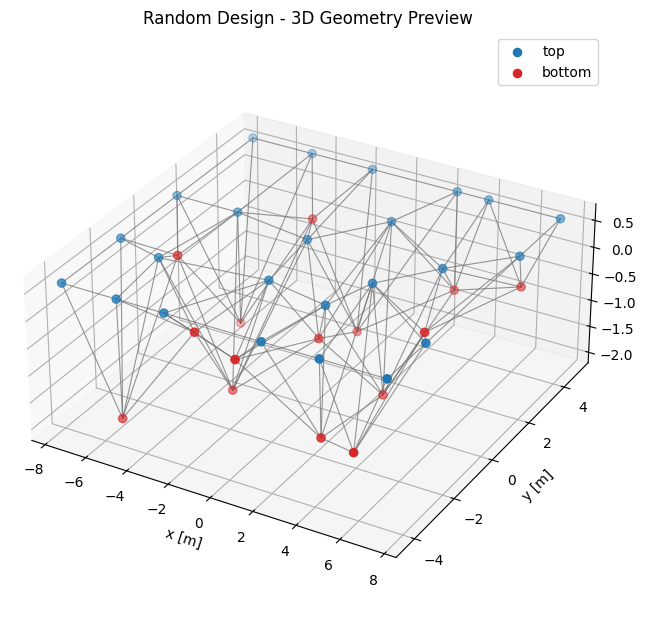

In [23]:
import importlib
import matplotlib.pyplot as plt
import config
import c24_stage_geometry as stage_geometry

importlib.reload(stage_geometry)

geometry_out = stage_geometry.run_random_geometry_stage(
    json_path=json_path if "json_path" in globals() else None,
    optimizer_search_space=optimizer_search_space if "optimizer_search_space" in globals() else None,
    sample_id=0,
)

my_random_design = geometry_out["my_random_design"]
vertices_list = geometry_out["vertices_list"]
df_vertices = geometry_out["df_vertices"]
df_edges = geometry_out["df_edges"]
df_geometry_overview = geometry_out["df_geometry_overview"]

print(f"Geometry: {len(df_vertices)} nodes, {len(df_edges)} members")
print(
    f"Length range [m]: {df_geometry_overview['length_m'].min():.3f}"
    f" - {df_geometry_overview['length_m'].max():.3f}"
)
display(df_geometry_overview[["edge_id", "V1", "V2", "length_m"]].head(5))

# saving the df_vertices and df_edges for later use
df_vertices.to_csv(config.DATA_IO_PATH / "df_vertices.csv", index=False)
df_edges.to_csv(config.DATA_IO_PATH / "df_edges.csv", index=False)

fig, ax = stage_geometry.plot_geometry_preview(
    df_vertices=df_vertices,
    df_edges=df_edges,
    figsize=(8, 7),
)
plt.show()

# Feasibility check

In [24]:
# =============================================================================
# Feasibility Check: Filter cost matrix before MILP
# =============================================================================
# Uses the c25_stage_feasibility module to validate slot-stock combinations
# based on: 1) Length constraints, 2) EC5 structural capacity with buckling

import numpy as np
from workflows import c25_stage_feasibility as stage_feas

# =============================================================================
# EXTRACT GEOMETRY FROM PREVIOUS CELLS
# =============================================================================

# Parse geometry from df_vertices and df_edges (generated in GEOMETRY cell)
verts = df_vertices[df_vertices['sample_id'] == 0].copy()
verts['v_idx'] = verts['vertex_index'].str.replace('v', '').astype(int)
verts = verts.sort_values('v_idx').reset_index(drop=True)
node_positions = verts[['x', 'y', 'z']].values   # [39, 3] metres

support_nodes = verts[verts['attribute'] == 'support']['v_idx'].tolist()
load_nodes    = verts[verts['attribute'] == 'load']['v_idx'].tolist()

print(f"Geometry loaded:")
print(f"  Nodes: {len(verts)}, Members: {len(df_edges)}")
print(f"  Support nodes: {support_nodes}")
print(f"  Load nodes: {load_nodes}")
print()

# =============================================================================
# RUN FEASIBILITY FILTER
# =============================================================================

# Build feasibility mask for current geometry
df_slots, feasibility_mask, member_forces, stats = stage_feas.build_cost_filter(
    node_positions=node_positions,
    edges_df=df_edges,
    stock_df=df_input_stock,
    support_nodes=support_nodes,
    load_nodes=load_nodes,
)

# =============================================================================
# DISPLAY SUMMARY
# =============================================================================

print("\n" + "="*70)
print("FEASIBILITY FILTER SUMMARY")
print("="*70)
for k, v in stats.items():
    if isinstance(v, list):
        print(f"  {k:<35} {v}")
    elif isinstance(v, float):
        print(f"  {k:<35} {v:.4f}")
    else:
        print(f"  {k:<35} {v}")

print()
print(f"Member forces:")
print(f"  Tension     (N > 0): {(member_forces >  1.0).sum()} members")
print(f"  Compression (N < 0): {(member_forces < -1.0).sum()} members")
print(f"  Near-zero:           {(np.abs(member_forces) <= 1.0).sum()} members")
print(f"  Max tension:         {member_forces.max()/1000:.2f} kN")
print(f"  Max compression:     {member_forces.min()/1000:.2f} kN")

print("\n✓ Feasibility mask ready for cost matrix filtering")

feasibility_mask_df = pd.DataFrame(feasibility_mask)
display(feasibility_mask_df.head())

Geometry loaded:
  Nodes: 39, Members: 120
  Support nodes: [0, 5, 18, 23]
  Load nodes: [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22]

Cost matrix filter: 120 slots × 506 stock = 60,720 combinations
  Load: 270.0 kN total  (2.00 kN/m² × 135 m²)
  Stage 1 (length):    48,337 eliminated  (12,383 remaining, 20.4%)
  Force estimation:    max tension=26.1 kN  max compression=-22.5 kN  mean |F|=5.5 kN
  Stage 3 (EC5):           88 eliminated  (12,295 remaining, 20.2%)

FEASIBILITY FILTER SUMMARY
  total_combinations                  60720
  after_length_filter                 12383
  after_structural_filter             12295
  pct_feasible                        20.2487
  slots_no_feasible_stock             []
  n_tension_members                   34
  n_compression_members               60
  max_tension_kn                      26.0998
  max_compression_kn                  -22.4582

Member forces:
  Tension     (N > 0): 34 members
  Compression (N < 0): 60 members

,0,1,2,3,4,5,6,7,8,9,...,496,497,498,499,500,501,502,503,504,505
0,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,True,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# COST, MATCHING, GNN AND FITNESS

In [25]:
import importlib
import json
import pandas as pd
import config
from workflows import c26_stage_cost_matrix as stage_cost
from workflows import c27_stage_milp as stage_milp
from workflows import c29_stage_fitness as stage_fitness

importlib.reload(stage_cost)
importlib.reload(stage_milp)
importlib.reload(stage_fitness)

LARGE_PENALTY = 1e9

# -------------------------------
# STEP 1: COST MATRIX STAGE
# -------------------------------
target_slot_for_analysis = "e60"

cost_matrix, stock_prepared, logs = stage_cost.build_cost_matrix(
    df_slots=df_slots,
    df_input_stock=df_input_stock,
    feasibility_mask=feasibility_mask,
)

# save cost matrix for later analysis
cost_matrix_df = pd.DataFrame(cost_matrix)
cost_matrix_df.to_csv(config.EXPORT_PATH / "c26_cost_matrix.csv")

# -------------------------------
# STEP 2: MILP STAGE
# -------------------------------
if len(stats["slots_no_feasible_stock"]) > 0:
    fitness = LARGE_PENALTY  # skip MILP, penalise GA
    raise ValueError(f"MILP skipped: {len(stats['slots_no_feasible_stock'])} slot(s) have no feasible stock.")

print("Starting MILP optimizer...")
milp_out = stage_milp.run_milp_stage(
    cost_matrix=cost_matrix,
    enriched_stock=stock_prepared,
    df_slots=df_slots,
    reclaimed_marker="RS",
    new_marker="NS",
    new_stock_max_uses=100,
    solver_msg=False,
    raise_on_infeasible_slots=True,
)

status = milp_out["status"]
df_results = milp_out["df_results"]
total_cost = milp_out["total_cost"]
milp_summary = milp_out["summary"]

df_results.to_csv(config.EXPORT_PATH / "c27_milp_results.csv", index=False)

print(
    f"MILP setup: {milp_summary['reclaimed_items']} reclaimed + "
    f"{milp_summary['new_items']} new stock items for {milp_summary['slots']} slots"
)
print(f"MILP status: {status}")
print(f"Total assignment cost: {total_cost:.2f}")
if len(df_results) > 0:
    display(df_results.head(10))

Starting MILP optimizer...
MILP setup: 64 reclaimed + 442 new stock items for 120 slots
MILP status: Optimal
Total assignment cost: 124.09


,edge_id,assigned_timber,CO2_Penalty
0,e0,NS_00152,1.078236
1,e1,NS_00152,1.078236
2,e2,NS_00152,0.924202
3,e3,NS_00152,0.936950
4,e4,NS_00436,1.847622
5,e5,NS_00278,1.420689
6,e6,NS_00152,1.078236
7,e7,NS_00152,0.974194
8,e8,NS_00237,1.232373
9,e9,NS_00318,1.609386


In [34]:
# -------------------------------
# Step 3: GNN FEASIBILITY CHECK
# -------------------------------
import importlib
import numpy as np
import torch
import config
import c21_surrogate_model_v4
from workflows import c28_stage_GNN as stage_gnn

importlib.reload(c21_surrogate_model_v4)
importlib.reload(stage_gnn)

# =============================================================================
# ARTIFACT PATHS
# =============================================================================
ARTIFACT_STEM    = "ID20260510_224228_LR3e-04_EP150_BS32_FA0.50_ROC0.874"
_artifact_dir    = config.SM_EXPORT_PATH / ARTIFACT_STEM
CKPT_PATH        = _artifact_dir / f"{ARTIFACT_STEM}.pth"
NORM_STATS_PATH  = _artifact_dir / f"{ARTIFACT_STEM}_norm_stats.pt"
EDGE_INDEX_PATH  = _artifact_dir / f"{ARTIFACT_STEM}_edge_index.json"
INFERENCE_CONFIG = _artifact_dir / f"{ARTIFACT_STEM}_inference_config.json"
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"

# =============================================================================
# LOAD MODEL  (call once; reuse across iterations inside GA loop)
# =============================================================================
model_bundle = stage_gnn.load_gnn_model(
    ckpt_path             = CKPT_PATH,
    norm_stats_path       = NORM_STATS_PATH,
    edge_index_path       = EDGE_INDEX_PATH,
    inference_config_path = INFERENCE_CONFIG,
    device                = DEVICE,
)

# =============================================================================
# PREPARE STOCK FEATURES FOR GNN
# =============================================================================
# Stock CSV uses mm / N/mm²; GNN training used SI (m, N/m²).
# Compute section properties and convert to match the training feature space.
# EDGE_COLS = ["Area", "Length", "E", "Iy", "Iz", "J", "EA/L"]

stock_gnn = df_input_stock.copy()

b_m  = stock_gnn["Width"].values         * 1e-3   # mm → m
h_m  = stock_gnn["Depth"].values         * 1e-3   # mm → m
L_m  = stock_gnn["Length"].values        * 1e-3   # mm → m
E_pa = stock_gnn["E_modulus_eff"].values * 1e6    # N/mm² → N/m²

area_m2 = b_m * h_m
a_m = np.minimum(b_m, h_m)   # shorter side (Saint-Venant torsion approximation)
c_m = np.maximum(b_m, h_m)

stock_gnn["Area"]   = area_m2                                          # m²
stock_gnn["Length"] = L_m                                              # m
stock_gnn["E"]      = E_pa                                             # N/m²
stock_gnn["Iy"]     = b_m * h_m**3 / 12                               # m⁴
stock_gnn["Iz"]     = h_m * b_m**3 / 12                               # m⁴
stock_gnn["J"]      = a_m**3 * c_m / 3 * (1 - 0.63 * a_m / c_m)     # m⁴
stock_gnn["EA/L"]   = E_pa * area_m2 / L_m                            # N/m

# =============================================================================
# DERIVE milp_assignment — [120] positional row indices into stock_gnn
# =============================================================================
stock_id_to_idx = {mid: i for i, mid in enumerate(df_input_stock["Member_ID"])}

df_milp_sorted = df_results.copy()
df_milp_sorted["edge_num"] = df_milp_sorted["edge_id"].str.replace("e", "").astype(int)
df_milp_sorted = df_milp_sorted.sort_values("edge_num").reset_index(drop=True)
milp_assignment = np.array([stock_id_to_idx[tid] for tid in df_milp_sorted["assigned_timber"]])

print(f"milp_assignment: shape={milp_assignment.shape},  unique stocks used: {len(set(milp_assignment))}")

# =============================================================================
# RUN GNN FEASIBILITY CHECK
# =============================================================================
feasibility_score, unsafe_member_ids, preds_physical = stage_gnn.gnn_feasibility(
    node_positions  = node_positions,
    milp_assignment = milp_assignment,
    stock_df        = stock_gnn,
    model_bundle    = model_bundle,
)

structural_penalty = stage_gnn.structural_fitness_penalty(feasibility_score, unsafe_member_ids)

print(f"\nGNN Feasibility Results:")
print(f"  Feasibility score:  {feasibility_score:.4f}  (1.0 = all members predicted safe)")
print(f"  Unsafe members:     {len(unsafe_member_ids)} / {stage_gnn.NUM_EDGES_PHYSICAL}")
print(f"  Structural penalty: {structural_penalty:.4f}  (w_structural=0.3)")
if unsafe_member_ids:
    print(f"  Unsafe member IDs:  {unsafe_member_ids[:20]}{'...' if len(unsafe_member_ids) > 20 else ''}")

[GNN] Loaded checkpoint from epoch 146  val_loss=0.042885
[TrussEdgeSafetyGNN] Topology cached: 240 edges
[GNN] Model ready on cpu  |  edge_index: torch.Size([2, 240])  |  threshold: 0.35
milp_assignment: shape=(120,),  unique stocks used: 53

GNN Feasibility Results:
  Feasibility score:  0.1083  (1.0 = all members predicted safe)
  Unsafe members:     107 / 120
  Structural penalty: 0.2675  (w_structural=0.3)
  Unsafe member IDs:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21]...


In [35]:
# -------------------------------
# STEP 3.5: FITNESS NORMALIZATION BOUNDS
# -------------------------------
import c29_stage_fitness as stage_fitness

bounds_out = stage_fitness.run_normalization_bounds_stage(
    cost_matrix=cost_matrix,
    df_logs=logs,
    enriched_stock=stock_prepared,
    df_slots=df_slots,
    reclaimed_marker="RS",
    new_marker="NS",
    new_stock_max_uses=100,   # match your c27 call
    solver_msg=False,
    print_summary=True,
)

normalization_constants = bounds_out["normalization_constants"]
print(normalization_constants)
# -> {"C_max": ..., "R_max": ..., "W_max": ...}

Bounds status: Optimal
Normalization constants C_max=228.07880160981992, R_max=53.333333333333336, W_max=6.442691699760355
{'C_max': 228.07880160981992, 'R_max': 53.333333333333336, 'W_max': 6.442691699760355}


In [36]:
# -------------------------------
# STEP 4: FITNESS STAGE
# -------------------------------
fitness_weights = {
    "omega_1": 1.0,
    "omega_2": 1.0,
    "omega_3": 1.0,
}

fitness_out = stage_fitness.run_fitness_stage(
    df_results=df_results,
    enriched_stock=stock_prepared,
    df_slots=df_slots,
    total_cost=total_cost,
    weight_config=fitness_weights,
    normalization_constants=normalization_constants,
    derive_normalization_constants=False,
    run_sanity_checks=True,
    print_breakdown=True,
)

fitness_result = fitness_out["fitness_result"]
normalization_constants = fitness_out["normalization_constants"]

print("Fitness summary:")
print(f"  objective: {fitness_result.get('objective', 'n/a')}")
print(f"  feasible: {fitness_result.get('is_feasible', 'n/a')}")
print(f"  fitness: {fitness_result.get('fitness', 'n/a')}\n")

# Notebook-owned fitness exports
fitness_json_path = config.EXPORT_PATH / "c28_fitness_result.json"
fitness_csv_path = config.EXPORT_PATH / "c28_fitness_result.csv"

fitness_json_path.parent.mkdir(parents=True, exist_ok=True)

# Convert numpy scalars to native Python values for stable JSON serialization.
def _to_builtin(value):
    return value.item() if hasattr(value, "item") else value

fitness_export = {key: _to_builtin(value) for key, value in fitness_result.items()}
fitness_export["weights"] = {
    "omega_1": float(fitness_weights["omega_1"]),
    "omega_2": float(fitness_weights["omega_2"]),
    "omega_3": float(fitness_weights["omega_3"]),
}
fitness_export["normalization_constants"] = {
    "C_max": float(normalization_constants["C_max"]),
    "R_max": float(normalization_constants["R_max"]),
    "W_max": float(normalization_constants["W_max"]),
}

with open(fitness_json_path, "w", encoding="utf-8") as f:
    json.dump(fitness_export, f, indent=2)

fitness_row = {
    **{key: _to_builtin(value) for key, value in fitness_result.items()},
    **fitness_weights,
    "C_max": float(normalization_constants["C_max"]),
    "R_max": float(normalization_constants["R_max"]),
    "W_max": float(normalization_constants["W_max"]),
}
pd.DataFrame([fitness_row]).to_csv(fitness_csv_path, index=False)

print(f"Exported fitness JSON: {fitness_json_path}")
print(f"Exported fitness CSV: {fitness_csv_path}")


MULTI-OBJECTIVE FITNESS EVALUATION

Raw Metrics:
  MILP Cost:         124.089 kg CO2e
  Reuse Rate:           36.7 %
  Total Waste:       10.8384 m3

Normalized (0-1 range):
  Cost (norm):         0.544
  Reuse (norm):        0.687
  Waste (norm):        1.000

Weights Applied:
  omega_1 (cost):      1.000
  omega_2 (reuse):     1.000
  omega_3 (waste):     1.000

Weighted Components:
  omega_1 x cost:      0.544
  omega_2 x reuse:     0.687 (subtracted)
  omega_3 x waste:     1.000

Final Fitness:
  F(x) = 0.544 - 0.687 + 1.000
  F(x) =    0.857

Interpretation:
  [POOR] Cost, waste, or low reuse is dominating the solution
  Bands: <= -0.25 excellent, <= 0.25 good, <= 0.75 fair, > 0.75 poor

Fitness summary:
  objective: 124.08854572801577
  feasible: True
  fitness: 0.8565599689764117

Exported fitness JSON: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c28_fitness_result.json
Exported fitness CSV: C:\Users\jaspe\OneDrive\06 Building Technology TU\2

# EXPORT

Exports structural parameters (vertices + edges with assigned timber) for Grasshopper reconstruction.

In [ ]:
# Export geometry + matching results
import pandas as pd
import config

EXPORT_PREFIX = "c29_optimum"
required_vars = ["df_vertices", "df_edges", "df_results"]
if any(name not in globals() for name in required_vars):
    raise ValueError(f"Missing: {', '.join(required_vars)}")

df_edges_export = pd.merge(df_edges, df_results[["edge_id", "assigned_timber", "CO2_Penalty"]], on="edge_id", how="left")
df_edges_export["assigned_timber"] = df_edges_export["assigned_timber"].fillna("UNASSIGNED")
df_edges_export["CO2_Penalty"] = df_edges_export["CO2_Penalty"].fillna(0)

df_vertices.to_csv(config.EXPORT_PATH / f"{EXPORT_PREFIX}_vertices.csv", index=False)
df_edges_export.to_csv(config.EXPORT_PATH / f"{EXPORT_PREFIX}_edges.csv", index=False)
n_matched = int((df_edges_export["assigned_timber"] != "UNASSIGNED").sum())
print(f"Exported: {len(df_vertices)} vertices, {len(df_edges_export)} edges ({n_matched} matched)")

# LITERATURE

### COST MATRIX
We now use one universal assignment formula for both reclaimed and new timber in the same cost matrix:

$$C_{i,j} = E_{embodied,i} + E_{prep,i} + E_{trans,i,j} + E_{waste,i,j} + E_{saw,i,j}$$

With:
- $E_{embodied,i} = V_{stock,i} \cdot M_{material,i}$ (from `ECC` in stock data)
- $E_{prep,i} = V_{stock,i} \cdot E_{prep}$
- $E_{trans,i,j} = \left(\frac{(V_{req}+V_{over})\cdot\rho}{1000}\right)\cdot D\cdot F_{trans}$
- $E_{waste,i,j} = V_{waste} \cdot E_{EoL}$
- $E_{saw,i,j} = P_{cut}$ when cutting is required, else 0

Interpretation by timber type:
- New timber: typically high `ECC`, usually low/zero preparation factor
- Reclaimed timber: `ECC` near 0, non-zero preparation factor

### MATCHING ALGORITHM / MILP
The assignment problem in this notebook is solved as a mixed-integer linear program (MILP). Let:

- $I$ be the set of required structural slots,
- $J$ be the set of inventory stock elements,
- $F \subseteq I \times J$ be the set of physically feasible slot-stock combinations,
- $R \subseteq J$ be the subset of reclaimed timber,
- $N \subseteq J$ be the subset of new timber,
- $c_{ij}$ be the cost of assigning stock element $j$ to slot $i$,
- $x_{ij} \in \{0,1\}$ be the decision variable, where $x_{ij}=1$ means that stock element $j$ is assigned to slot $i$.

$$
\min_{x} \sum_{(i,j) \in F} c_{ij} x_{ij}
$$

subject to

$$
\sum_{j:(i,j)\in F} x_{ij} = 1 \qquad \forall i \in I
$$

$$
\sum_{i:(i,j)\in F} x_{ij} \le 1 \qquad \forall j \in R
$$

$$
\sum_{i:(i,j)\in F} x_{ij} \le |I| \qquad \forall j \in N
$$

$$
x_{ij} = 0 \qquad \forall (i,j) \notin F
$$

In words: every structural member must receive exactly one feasible timber element, reclaimed timber can be used at most once, and new timber can be reused when physically feasible.

### MULTI-OBJECTIVE FITNESS FUNCTION

The fitness function balances three competing objectives:

$$F(\mathbf{x}) = \omega_1 \left( \frac{f_{inner}^*(\mathbf{x})}{\mathcal{C}_{max}} \right) - \omega_2 \left( \frac{\mathcal{R}(\mathbf{x}, \mathbf{y}^*)}{\mathcal{R}_{max}} \right) + \omega_3 \left( \frac{\mathcal{W}(\mathbf{x}, \mathbf{y}^*)}{\mathcal{W}_{max}} \right)$$

- **$f_{inner}^*$**: MILP cost (kg CO2e) — penalizes virgin material and waste
- **$\mathcal{R}$**: Reuse rate (%) — reward for using reclaimed timber (subtracted, so higher reuse = better)
- **$\mathcal{W}$**: Total waste (m³) — penalizes inefficient cutting
- **$\omega_i$**: Weight coefficients to tune priorities

All metrics are normalized to [0, 1] using precomputed dataset-driven extremes ($\mathcal{C}_{max}$, $\mathcal{R}_{max}$, $\mathcal{W}_{max}$).

**Design philosophy**: The MILP cost matrix already accounts for all physical and geometric infeasibilities (by returning ∞ for impossible assignments). This means the upper-level fitness function does NOT need a conditional fallback loop. Instead, we can directly minimize a weighted multi-objective sum.

**Sign convention**:
- Positive coefficient on cost: higher MILP cost → higher (worse) fitness
- Negative coefficient on reuse: higher reuse rate → lower (better) fitness ✓
- Positive coefficient on waste: higher waste → higher (worse) fitness

**Typical design trade-offs**:
- High ω₁ (cost weight): prioritize LCA minimization across all materials
- High ω₂ (reuse weight): prioritize reclaimed material recovery
- High ω₃ (waste weight): prioritize cutting efficiency